## Python para Ciência de Dados - Projeto Final


Equipe:

Michele Mayumi Miyazaki <br>
Charlene Aparecida Salustino de Jesus <br>
Edimilson Estevam da Cruz <br>
Lucas Cinquetti Moreira <br>

### Bibliotecas

In [86]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [87]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Input de dados

In [88]:
dataset = pd.read_csv('../data/gapminder_full.csv',delimiter=',')

In [89]:
dataset.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [90]:
dataset.shape

(1736, 6)

## EDA - Análise exploratória da Base principal

### Explorando distribuições dos dados

##### Quais são as colunas do Dataset?

In [91]:
dataset.columns

Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='str')

#### Colunas com valores numéricos:

In [92]:
numeric_cols = dataset.select_dtypes(include=["number"]).columns
print(numeric_cols)

Index(['year', 'pop', 'lifeExp', 'gdpPercap'], dtype='str')


#### Colunas com valores categóricos:

In [93]:
cat_cols = dataset.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['country', 'continent'], dtype='str')


/tmp/ipykernel_80793/3641821407.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dataset.select_dtypes(include=["object"]).columns


#### Descrição geral

In [94]:
dataset.describe()

,year,pop,lifeExp,gdpPercap
count,1736.000000,1.736000e+03,1736.000000,1736.000000
mean,1979.669931,3.156800e+07,59.511979,7240.155986
std,17.296364,1.172888e+08,12.956028,9839.873695
min,1952.000000,6.001100e+04,23.599000,241.165876
25%,1967.000000,2.818694e+06,48.245000,1202.060309
50%,1982.000000,7.150606e+06,60.808000,3534.772106
75%,1997.000000,1.977102e+07,70.945000,9380.254270
max,2007.000000,1.318683e+09,82.603000,113523.132900


#### Países que aparecem mais vezes no registro

Por exemplo, frança foi anotada em 19 anos. Possui 19 linhas da França no Dataset

In [95]:
dataset['country'].value_counts()

country
France                19
Bolivia               17
Guinea                17
China                 15
Ecuador               15
                      ..
Vietnam               12
West Bank and Gaza    12
Yemen Rep.            12
Zambia                12
Zimbabwe              12
Name: count, Length: 142, dtype: int64

#### Anos

In [96]:
dataset['year'].value_counts()

year
2007    148
1997    147
2002    147
1987    146
1962    144
1967    144
1972    144
1992    144
1952    143
1957    143
1977    143
1982    143
Name: count, dtype: int64

#### País com maior PIB

In [97]:
dataset.loc[dataset["gdpPercap"].idxmax()]

country           Kuwait
year                1957
pop             212846.0
continent           Asia
lifeExp           58.033
gdpPercap    113523.1329
Name: 885, dtype: object

#### País com menor PIB

In [98]:
dataset.loc[dataset["gdpPercap"].idxmin()]

country      Congo Dem. Rep.
year                    2002
pop               55379852.0
continent             Africa
lifeExp               44.966
gdpPercap         241.165876
Name: 343, dtype: object

#### País com maior expectativa de vida

In [99]:
dataset.loc[dataset["lifeExp"].idxmax()]

country            Japan
year                2007
pop          127467972.0
continent           Asia
lifeExp           82.603
gdpPercap    31656.06806
Name: 835, dtype: object

#### País com menor expectativa de vida

In [100]:
dataset.loc[dataset["lifeExp"].idxmin()]

country          Rwanda
year               1992
pop           7290203.0
continent        Africa
lifeExp          23.599
gdpPercap    737.068595
Name: 1324, dtype: object

## Análises Gráficas

#### 20 países com maior PIB

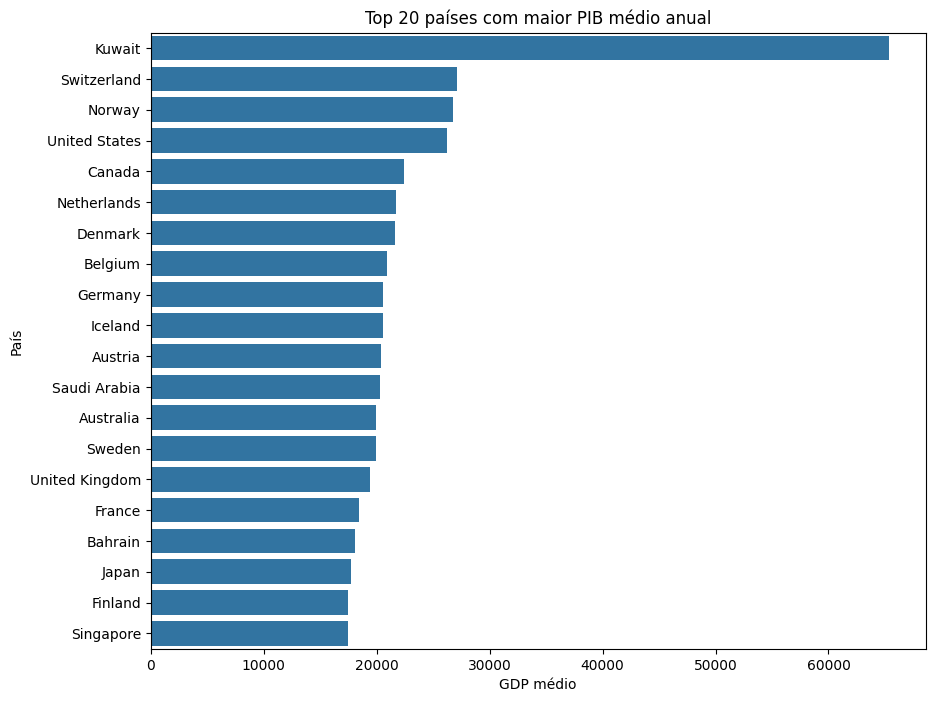

In [101]:
pib_country = (
    dataset.groupby("country")["gdpPercap"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=pib_country.values,
    y=pib_country.index
)

plt.title("Top 20 países com maior PIB médio anual")
plt.xlabel("GDP médio")
plt.ylabel("País")

plt.show()

#### 20 países com menor PIB

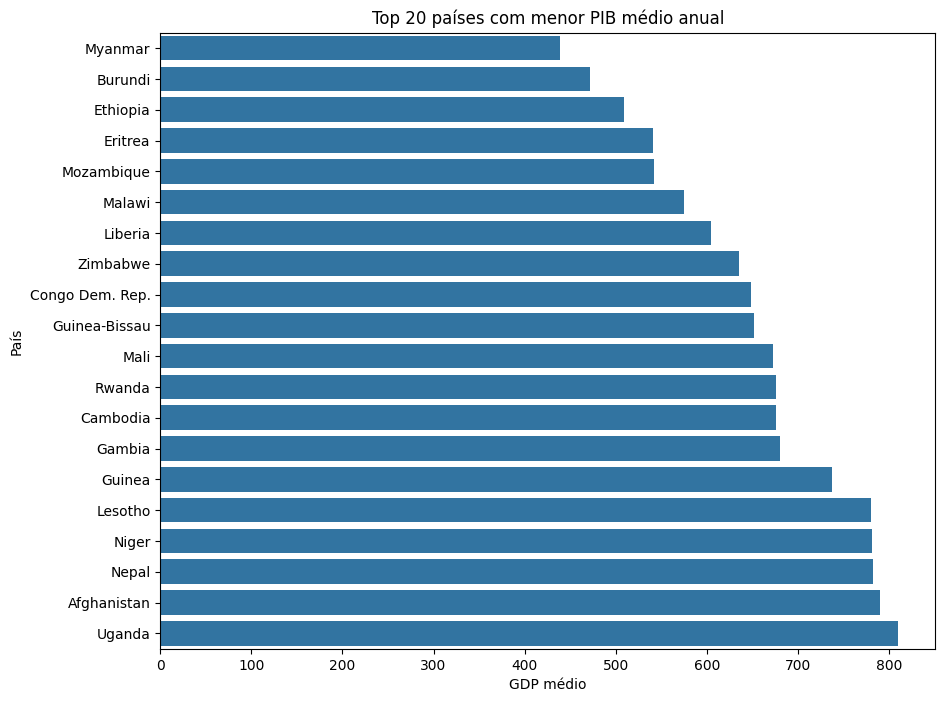

In [102]:
pib_country = (
    dataset.groupby("country")["gdpPercap"]
    .mean()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=pib_country.values,
    y=pib_country.index
)

plt.title("Top 20 países com menor PIB médio anual")
plt.xlabel("GDP médio")
plt.ylabel("País")

plt.show()

#### Países com maior expectativa de vida

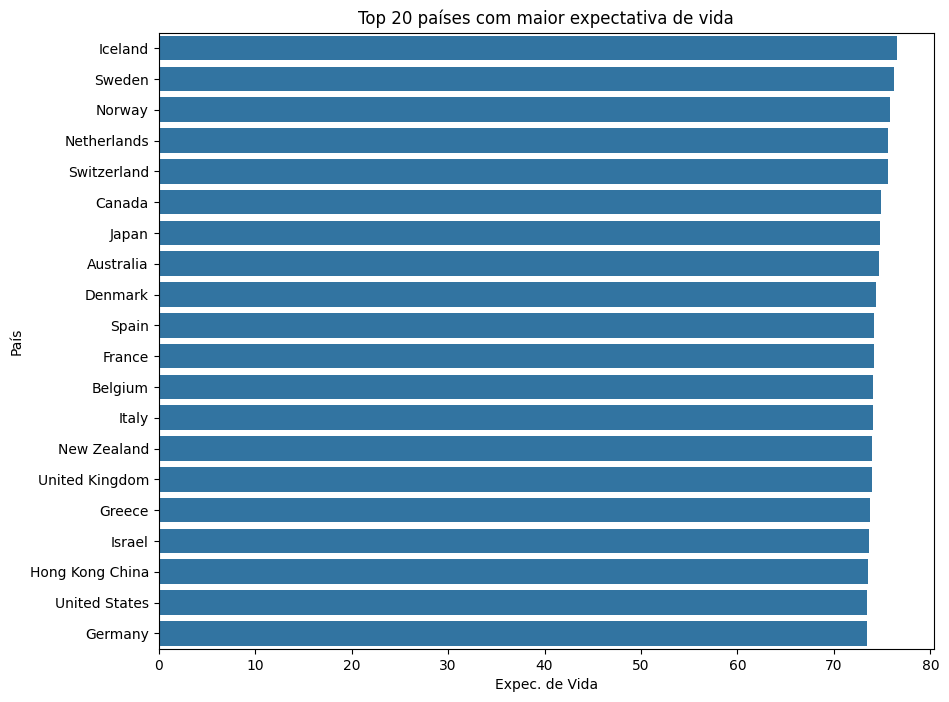

In [103]:
pib_country = (
    dataset.groupby("country")["lifeExp"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=pib_country.values,
    y=pib_country.index
)

plt.title("Top 20 países com maior expectativa de vida")
plt.xlabel("Expec. de Vida")
plt.ylabel("País")

plt.show()

#### Países com menor expectativa de Vida

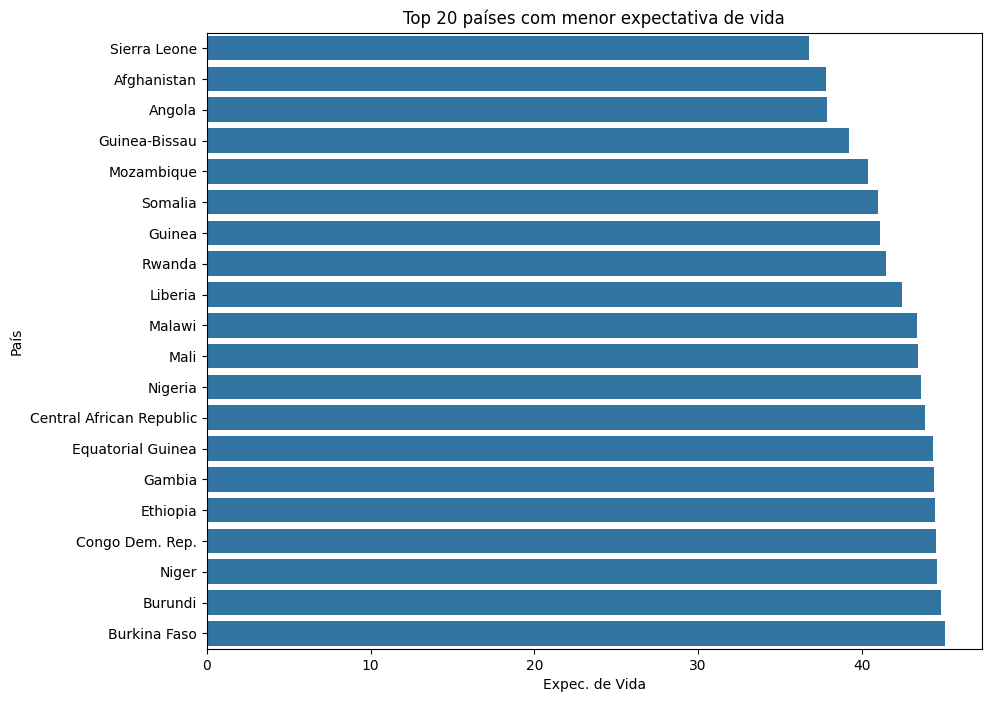

In [104]:
pib_country = (
    dataset.groupby("country")["lifeExp"]
    .mean()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=pib_country.values,
    y=pib_country.index
)

plt.title("Top 20 países com menor expectativa de vida")
plt.xlabel("Expec. de Vida")
plt.ylabel("País")

plt.show()

#### Países com maior GDP por continente

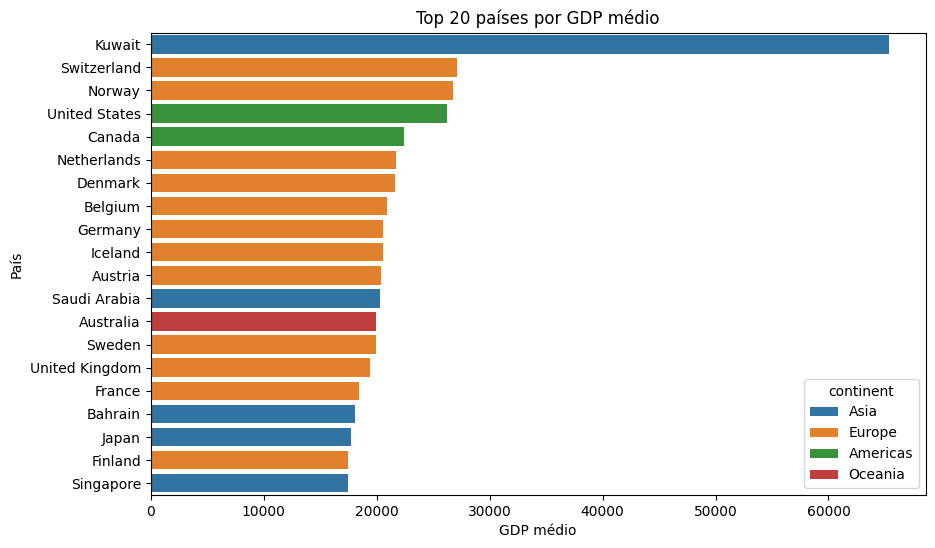

In [105]:
pib_country = (
    dataset.groupby(["country", "continent"])["gdpPercap"]
    .mean()
    .reset_index()
)

top_pib = pib_country.sort_values(
    by="gdpPercap",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_pib,
    x="gdpPercap",
    y="country",
    hue="continent"
)

plt.title("Top 20 países por GDP médio")
plt.xlabel("GDP médio")
plt.ylabel("País")

plt.show()

#### Anos em que foi realizado coleta

### Países com maior expectativa de vida antes dos anos 1990

In [106]:
df_before_2000 = dataset.copy()
df_after_2000 = dataset.copy()

In [107]:
df_before_2000 = df_before_2000[df_before_2000["year"] < 1990]

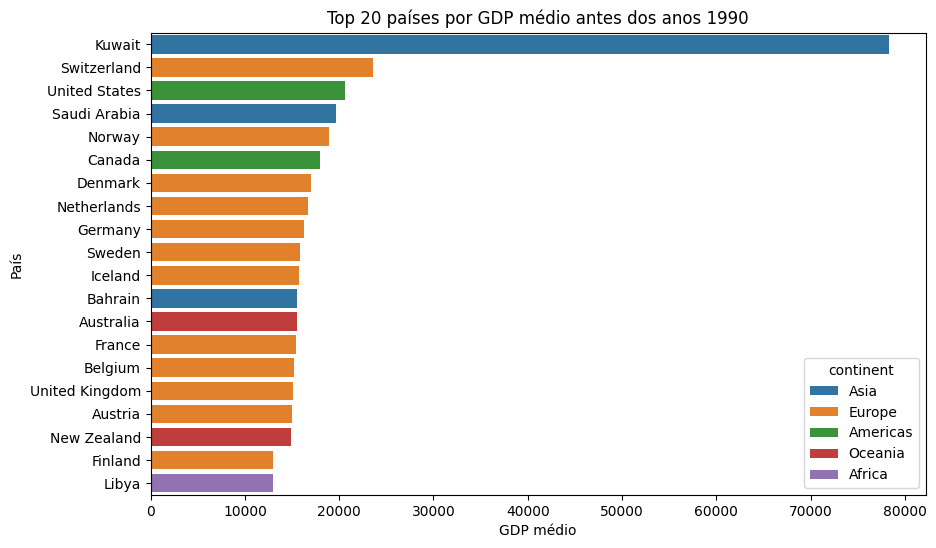

In [108]:
pib_country = (
    df_before_2000.groupby(["country", "continent"])["gdpPercap"]
    .mean()
    .reset_index()
)

top_pib = pib_country.sort_values(
    by="gdpPercap",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_pib,
    x="gdpPercap",
    y="country",
    hue="continent"
)

plt.title("Top 20 países por GDP médio antes dos anos 1990")
plt.xlabel("GDP médio")
plt.ylabel("País")

plt.show()

### Países com maior expectativa de vida após os anos 1990

In [109]:
df_after_2000 = df_after_2000[df_after_2000["year"] > 1990]

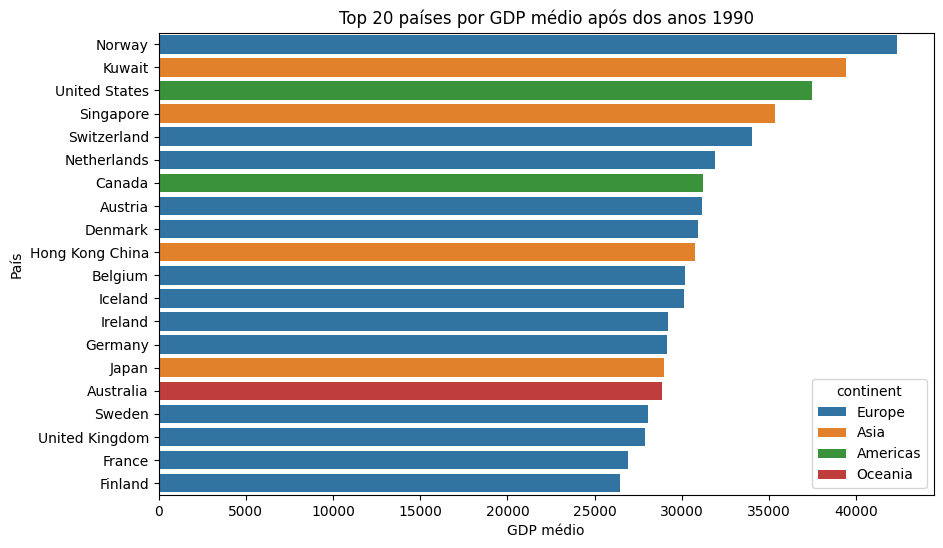

In [110]:
pib_country = (
    df_after_2000.groupby(["country", "continent"])["gdpPercap"]
    .mean()
    .reset_index()
)

top_pib = pib_country.sort_values(
    by="gdpPercap",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_pib,
    x="gdpPercap",
    y="country",
    hue="continent"
)

plt.title("Top 20 países por GDP médio após dos anos 1990")
plt.xlabel("GDP médio")
plt.ylabel("País")

plt.show()

#### Análise EUA

In [111]:
df_USA = dataset[dataset["country"] == "United States"]

In [112]:
df_USA.head(20)

,country,year,pop,continent,lifeExp,gdpPercap
1640,United States,1952,157553000.0,Americas,68.440,13990.48208
1641,United States,1957,171984000.0,Americas,69.490,14847.12712
1642,United States,1962,186538000.0,Americas,70.210,16173.14586
1643,United States,1967,198712000.0,Americas,70.760,19530.36557
1644,United States,1972,209896000.0,Americas,71.340,21806.03594
1645,United States,1977,220239000.0,Americas,73.380,24072.63213
1646,United States,1982,232187835.0,Americas,74.650,25009.55914
1647,United States,1987,242803533.0,Americas,75.020,29884.35041
1648,United States,1992,256894189.0,Americas,76.090,32003.93224
1649,United States,1997,272911760.0,Americas,76.810,35767.43303


#### Análise Kuwait

In [113]:
df_Kuwait = dataset[dataset["country"] == "Kuwait"]

In [114]:
df_Kuwait.head(20)

,country,year,pop,continent,lifeExp,gdpPercap
884,Kuwait,1952,160000.0,Asia,55.565,108382.35290
885,Kuwait,1957,212846.0,Asia,58.033,113523.13290
886,Kuwait,1962,358266.0,Asia,60.470,95458.11176
887,Kuwait,1967,575003.0,Asia,64.624,80894.88326
888,Kuwait,1972,841934.0,Asia,67.712,109347.86700
889,Kuwait,1977,1140357.0,Asia,69.343,59265.47714
890,Kuwait,1982,1497494.0,Asia,71.309,31354.03573
891,Kuwait,1987,1891487.0,Asia,74.174,28118.42998
892,Kuwait,1992,1418095.0,Asia,75.190,34932.91959
893,Kuwait,1997,1765345.0,Asia,76.156,40300.61996


In [115]:
df_3 = pd.read_csv('../data/gdp_pcapV2.csv', delimiter=',')

In [116]:
df_4 = df_3.copy()

In [117]:
df_kuwait_original = df_4[df_4["name"] == "Kuwait"]

df_kuwait_original.head()

,geo,name,1952,1953,1954,1955,1956,1957,1958,1959,...,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
94,kwt,Kuwait,12421.61591,16345.18731,18499.26283,20941.21802,23700.78031,26821.00907,30352.28491,34345.73484,...,58928.19815,56880.07903,58580.26386,57799.99596,58629.24067,67698.87165,73414.45772,78600.30407,80163.48958,80178.19205


In [118]:
anos_manter = ['1952', '1957', '1962', '1967', '1972', '1977', '1982', '1987', '1992', '1997', '2002', '2007']

df_kuwait_original = df_kuwait_original[anos_manter]

df_kuwait_original.head()


,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
94,12421.61591,26821.00907,49800.41204,70398.52158,101558.8449,58968.13539,33877.99251,34961.77712,34188.16891,57809.75925,58629.24067,80178.19205


In [119]:
df_kuwait_original.transpose()


,94
1952,12421.61591
1957,26821.00907
1962,49800.41204
1967,70398.52158
1972,101558.84490
1977,58968.13539
1982,33877.99251
1987,34961.77712
1992,34188.16891
1997,57809.75925


In [120]:
df_kuwait_original.columns

Index(['1952', '1957', '1962', '1967', '1972', '1977', '1982', '1987', '1992',
       '1997', '2002', '2007'],
      dtype='str')

In [121]:
df_kuwait_2 = df_Kuwait[['year', 'gdpPercap']]

In [122]:
df_kuwait_2

,year,gdpPercap
884,1952,108382.35290
885,1957,113523.13290
886,1962,95458.11176
887,1967,80894.88326
888,1972,109347.86700
889,1977,59265.47714
890,1982,31354.03573
891,1987,28118.42998
892,1992,34932.91959
893,1997,40300.61996


In [123]:
df_kuwait_original = (
    df_kuwait_original
    .T
    .reset_index()
)

df_kuwait_original.columns = ["year", "GDP2"]

In [124]:
df_kuwait_original

,year,GDP2
0,1952,12421.61591
1,1957,26821.00907
2,1962,49800.41204
3,1967,70398.52158
4,1972,101558.84490
5,1977,58968.13539
6,1982,33877.99251
7,1987,34961.77712
8,1992,34188.16891
9,1997,57809.75925


In [126]:
df_kuwait_original["year"] = df_kuwait_original["year"].astype(int)

In [127]:
df_analise_kuwait = pd.merge(df_kuwait_2, df_kuwait_original, on='year')

In [128]:
df_analise_kuwait

,year,gdpPercap,GDP2
0,1952,108382.35290,12421.61591
1,1957,113523.13290,26821.00907
2,1962,95458.11176,49800.41204
3,1967,80894.88326,70398.52158
4,1972,109347.86700,101558.84490
5,1977,59265.47714,58968.13539
6,1982,31354.03573,33877.99251
7,1987,28118.42998,34961.77712
8,1992,34932.91959,34188.16891
9,1997,40300.61996,57809.75925


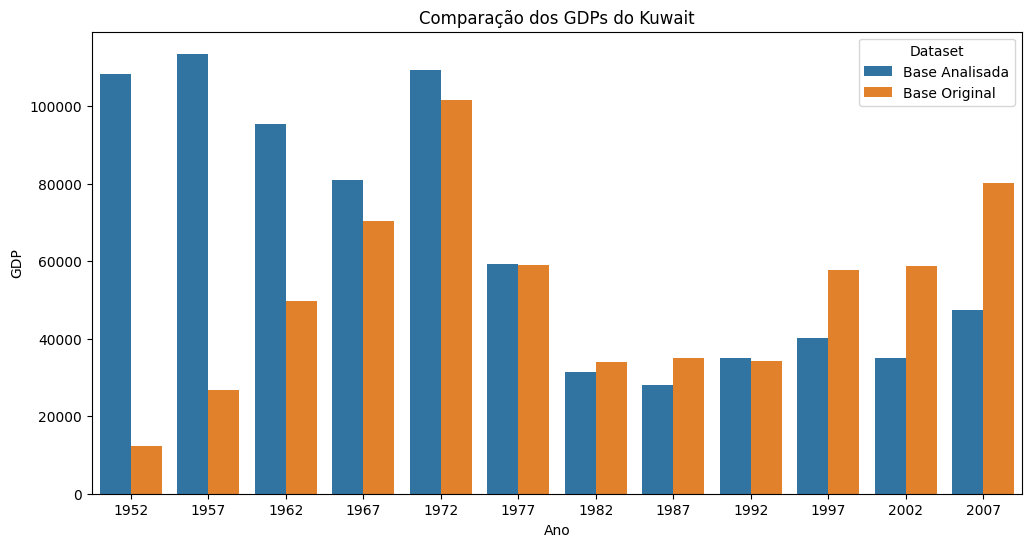

In [131]:
df_plot = df_analise_kuwait.melt(
    id_vars="year",
    value_vars=["gdpPercap", "GDP2"],
    var_name="Dataset",
    value_name="GDP_Value"
)

df_plot["Dataset"] = df_plot["Dataset"].replace({
    "GDP2": "Base Original",
    "gdpPercap": "Base Analisada"
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_plot,
    x="year",
    y="GDP_Value",
    hue="Dataset"
)

plt.title("Comparação dos GDPs do Kuwait")
plt.xlabel("Ano")
plt.ylabel("GDP")

plt.show()